In [2]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
%matplotlib inline
import seaborn as sns
print("Setup Complete")

Setup Complete


In [3]:
folder_path = r"D:\PTDLKinhDoanh\Dataset\all_fuels_data.csv"
df = pd.read_csv(folder_path) 

print(df.head()) 


  ticker  commodity        date       open       high        low      close  \
0   CL=F  Crude Oil  2000-08-23  31.950001  32.799999  31.950001  32.049999   
1   CL=F  Crude Oil  2000-08-24  31.900000  32.240002  31.400000  31.629999   
2   CL=F  Crude Oil  2000-08-25  31.700001  32.099998  31.320000  32.049999   
3   CL=F  Crude Oil  2000-08-28  32.040001  32.919998  31.860001  32.869999   
4   CL=F  Crude Oil  2000-08-29  32.820000  33.029999  32.560001  32.720001   

   volume  
0   79385  
1   72978  
2   44601  
3   46770  
4   49131  


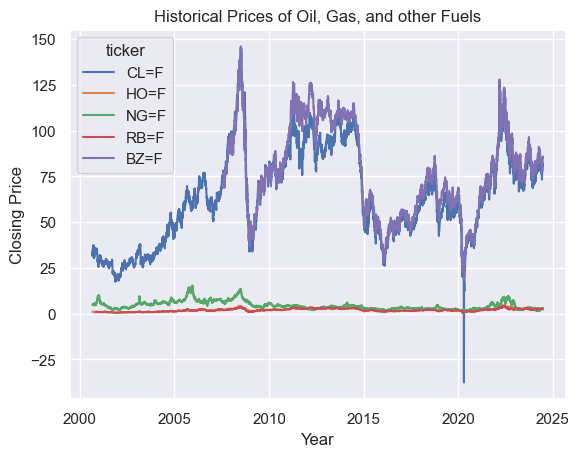

In [4]:
# Lineplot of entire dataset 
sns.set(style="darkgrid")
df['date'] = pd.to_datetime(df['date'])

sns.lineplot(x='date',y='close',hue='ticker',data=df)

plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xlabel('Year')
plt.ylabel('Closing Price')
plt.title('Historical Prices of Oil, Gas, and other Fuels')
plt.show()

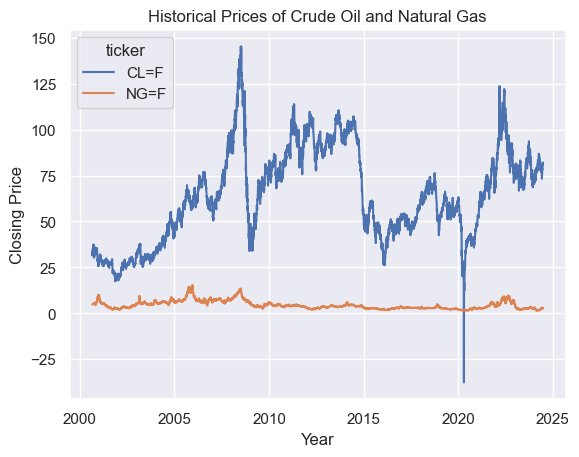

In [5]:
# List of tickers for filtered dataset
selected_commods = ['CL=F','NG=F']
# Using isin function, create new dataset with only our selected commodities
sub_oil_gas_data = df[df['ticker'].isin(selected_commods)]
#Display head to ensure data is correct
sub_oil_gas_data.tail()
#Plot data
sns.set(style="darkgrid")
sns.lineplot(x='date',y='close',hue='ticker',data=sub_oil_gas_data)
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xlabel('Year')
plt.ylabel('Closing Price')

plt.title('Historical Prices of Crude Oil and Natural Gas')
plt.show()

In [6]:
# Establish Start and End Dates
start_date = '2019-01-01'
end_date = '2024-01-01'
# filter our data to only include CL=F and NG=F during the window
Fiveyr_sub_oil_gas_data = sub_oil_gas_data[(sub_oil_gas_data['date'] >= start_date) & (sub_oil_gas_data['date'] <= end_date)]
# Print out head of 5 yr data to ensure the filter was properly applied
Fiveyr_sub_oil_gas_data.head()

,ticker,commodity,date,open,high,low,close,volume
4605,CL=F,Crude Oil,2019-01-02,45.799999,47.779999,44.349998,46.540001,850480
4606,CL=F,Crude Oil,2019-01-03,46.259998,47.490002,45.349998,47.090000,788718
4607,CL=F,Crude Oil,2019-01-04,46.900002,49.220001,46.650002,47.959999,817277
4608,CL=F,Crude Oil,2019-01-07,48.299999,49.790001,48.110001,48.520000,819939
4609,CL=F,Crude Oil,2019-01-08,48.730000,49.950001,48.310001,49.779999,765981


In [8]:
# Establish Start and End Dates
start_date = '2023-01-01'
end_date = '2024-01-01'
# filter our data to only include CL=F and NG=F during the window
Oneyr_sub_oil_gas_data = sub_oil_gas_data[(sub_oil_gas_data['date'] >= start_date) & (sub_oil_gas_data['date'] <= end_date)]
# Print out head of 5 yr data to ensure the filter was properly applied
Oneyr_sub_oil_gas_data.head()

,ticker,commodity,date,open,high,low,close,volume
5613,CL=F,Crude Oil,2023-01-03,80.570000,81.500000,76.599998,76.930000,338520
5614,CL=F,Crude Oil,2023-01-04,77.250000,77.419998,72.730003,72.839996,352434
5615,CL=F,Crude Oil,2023-01-05,73.250000,74.919998,72.459999,73.669998,300731
5616,CL=F,Crude Oil,2023-01-06,73.970001,75.470001,73.239998,73.769997,258128
5617,CL=F,Crude Oil,2023-01-09,73.470001,76.739998,73.470001,74.629997,329290


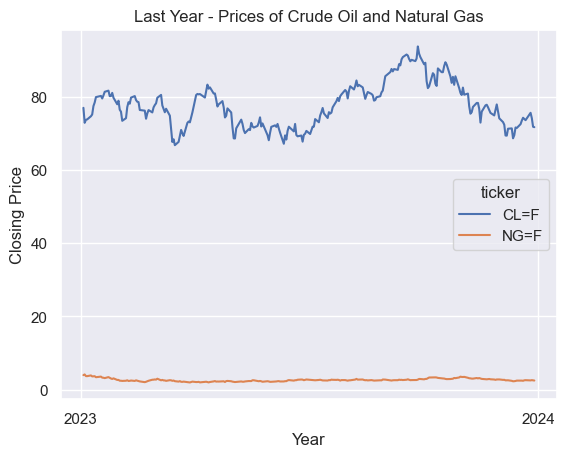

In [9]:
# Plot of last year data
sns.set(style="darkgrid")
sns.lineplot(x='date',y='close',hue='ticker',data=Oneyr_sub_oil_gas_data)
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xlabel('Year')
plt.ylabel('Closing Price')

plt.title('Last Year - Prices of Crude Oil and Natural Gas')
plt.show()

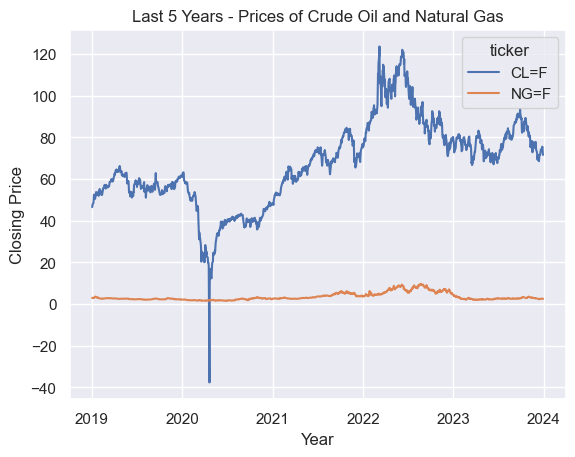

In [10]:
# Plot of 5 year data
sns.set(style="darkgrid")
sns.lineplot(x='date',y='close',hue='ticker',data=Fiveyr_sub_oil_gas_data)
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xlabel('Year')
plt.ylabel('Closing Price')

plt.title('Last 5 Years - Prices of Crude Oil and Natural Gas')
plt.show()

In [11]:
#Filter data set to just be oil
crude_oil = ['CL=F']
oil_data = Fiveyr_sub_oil_gas_data[Fiveyr_sub_oil_gas_data['ticker'].isin(crude_oil)]
oil_data.tail()

,ticker,commodity,date,open,high,low,close,volume
5859,CL=F,Crude Oil,2023-12-22,73.910004,74.980003,73.389999,73.559998,222600
5860,CL=F,Crude Oil,2023-12-26,73.559998,76.180000,73.129997,75.570000,208715
5861,CL=F,Crude Oil,2023-12-27,75.320000,75.660004,73.769997,74.110001,253323
5862,CL=F,Crude Oil,2023-12-28,73.800003,74.400002,71.720001,71.769997,262748
5863,CL=F,Crude Oil,2023-12-29,71.989998,72.620003,71.250000,71.650002,214486


In [12]:
# Establish Start and End Dates
start_date = '2023-01-01'
end_date = '2024-01-01'
# filter our data to only include CL=F and NG=F during the window
Oneyr_sub_oil_data = oil_data[(oil_data['date'] >= start_date) & (oil_data['date'] <= end_date)]
# Print out head of 5 yr data to ensure the filter was properly applied
Oneyr_sub_oil_data.head()

,ticker,commodity,date,open,high,low,close,volume
5613,CL=F,Crude Oil,2023-01-03,80.570000,81.500000,76.599998,76.930000,338520
5614,CL=F,Crude Oil,2023-01-04,77.250000,77.419998,72.730003,72.839996,352434
5615,CL=F,Crude Oil,2023-01-05,73.250000,74.919998,72.459999,73.669998,300731
5616,CL=F,Crude Oil,2023-01-06,73.970001,75.470001,73.239998,73.769997,258128
5617,CL=F,Crude Oil,2023-01-09,73.470001,76.739998,73.470001,74.629997,329290


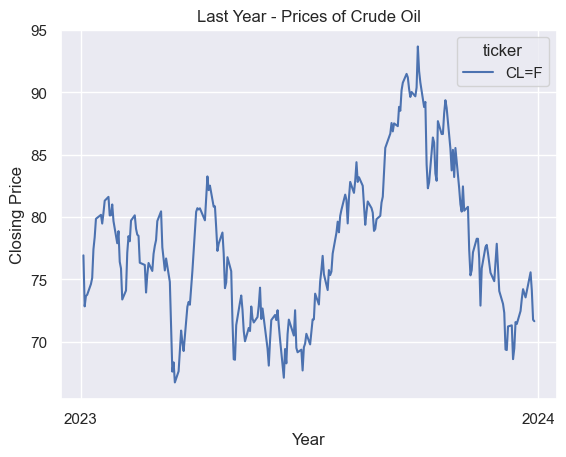

In [13]:
# Plot of year data - Crude Oil
sns.set(style="darkgrid")
sns.lineplot(x='date',y='close',hue='ticker',data=Oneyr_sub_oil_data)
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xlabel('Year')
plt.ylabel('Closing Price')

plt.title('Last Year - Prices of Crude Oil')
plt.show()

In [14]:
# Establish Start and End Dates
start_date = '2019-01-01'
end_date = '2024-01-01'
# filter our data to only include CL=F and NG=F during the window
Fiveyr_sub_oil_data = oil_data[(oil_data['date'] >= start_date) & (oil_data['date'] <= end_date)]
# Print out head of 5 yr data to ensure the filter was properly applied
Fiveyr_sub_oil_data.head()

,ticker,commodity,date,open,high,low,close,volume
4605,CL=F,Crude Oil,2019-01-02,45.799999,47.779999,44.349998,46.540001,850480
4606,CL=F,Crude Oil,2019-01-03,46.259998,47.490002,45.349998,47.090000,788718
4607,CL=F,Crude Oil,2019-01-04,46.900002,49.220001,46.650002,47.959999,817277
4608,CL=F,Crude Oil,2019-01-07,48.299999,49.790001,48.110001,48.520000,819939
4609,CL=F,Crude Oil,2019-01-08,48.730000,49.950001,48.310001,49.779999,765981


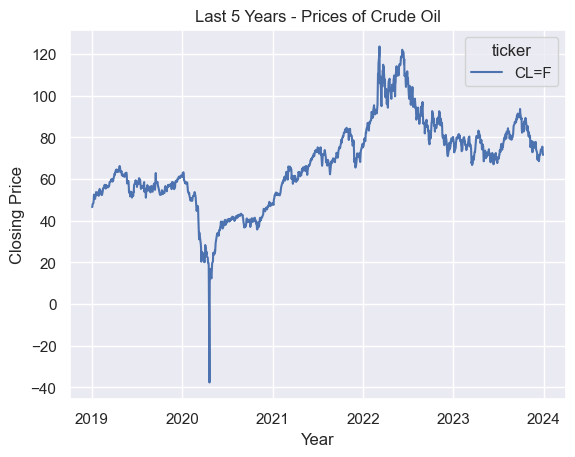

In [15]:
# Plot of 5 year data - Crude Oil
sns.set(style="darkgrid")
sns.lineplot(x='date',y='close',hue='ticker',data=Fiveyr_sub_oil_data)
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xlabel('Year')
plt.ylabel('Closing Price')

plt.title('Last 5 Years - Prices of Crude Oil')
plt.show()

Text(0.5, 1.0, 'Observed')

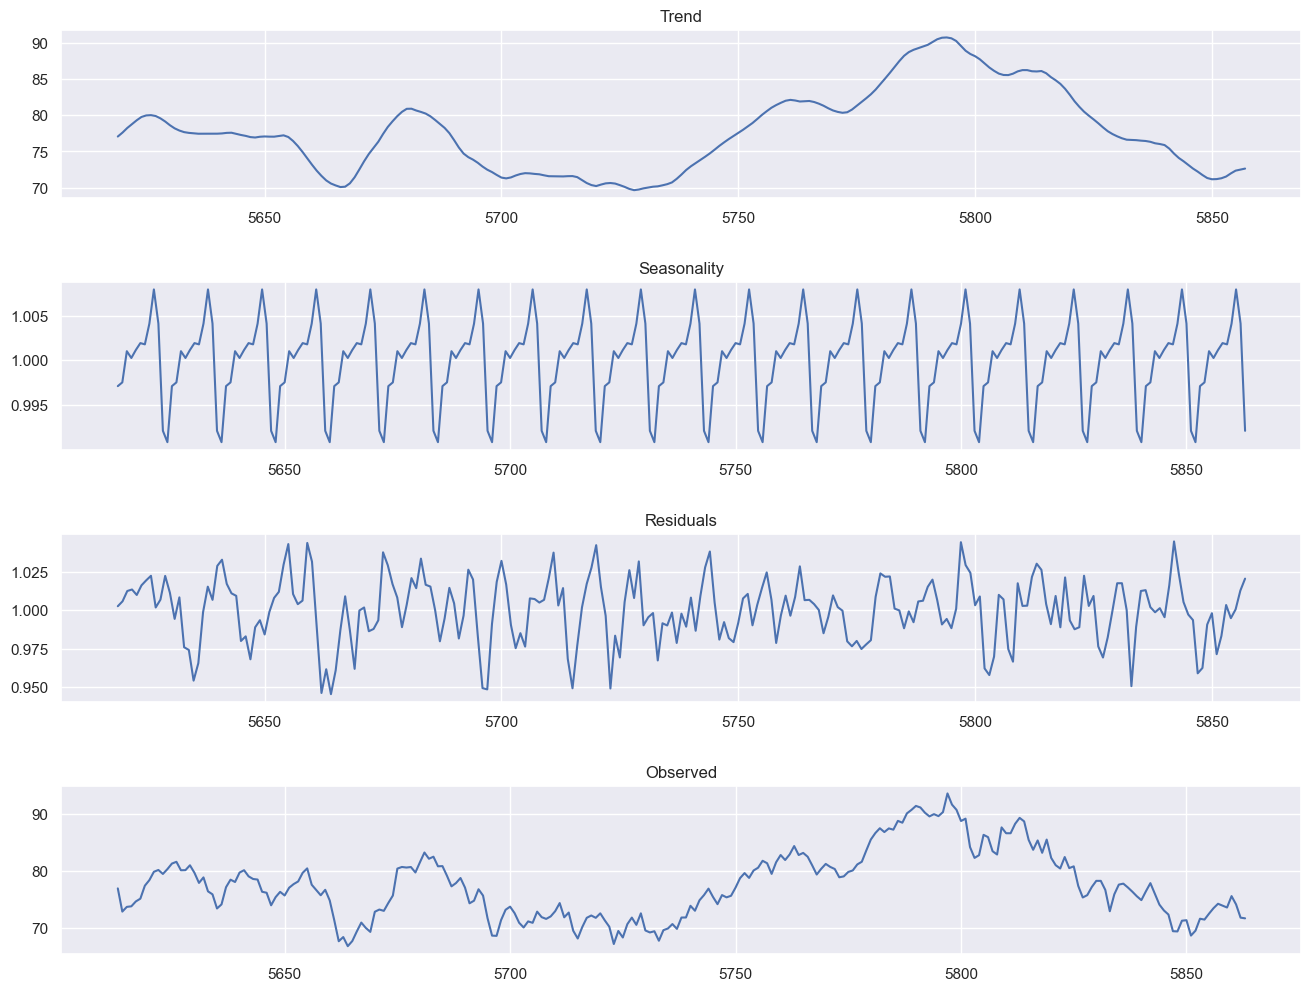

In [16]:
oil_decompose = seasonal_decompose(Oneyr_sub_oil_data['close'], model='multiplicative',period=12)
# Plot results
plt.figure(figsize=(16,12))
plt.subplots_adjust(hspace=0.5)

plt.subplot(4,1,1)
plt.plot(oil_decompose.trend)
plt.title('Trend')

plt.subplot(4,1,2)
plt.plot(oil_decompose.seasonal)
plt.title('Seasonality')

plt.subplot(4,1,3)
plt.plot(oil_decompose.resid)
plt.title('Residuals')

plt.subplot(4,1,4)
plt.plot(oil_decompose.observed)
plt.title('Observed')

In [17]:
#Filter data set to just be natural gas
natgas_oil = ['NG=F']
natgas_data = Fiveyr_sub_oil_gas_data[Fiveyr_sub_oil_gas_data['ticker'].isin(natgas_oil)]
natgas_data.tail()

,ticker,commodity,date,open,high,low,close,volume
17816,NG=F,Natural Gas,2023-12-22,2.584,2.620,2.528,2.610,42835
17817,NG=F,Natural Gas,2023-12-26,2.545,2.581,2.454,2.550,50762
17818,NG=F,Natural Gas,2023-12-27,2.580,2.722,2.562,2.619,129265
17819,NG=F,Natural Gas,2023-12-28,2.455,2.576,2.412,2.557,116059
17820,NG=F,Natural Gas,2023-12-29,2.539,2.561,2.489,2.514,89598


In [18]:
# Establish Start and End Dates
start_date = '2023-01-01'
end_date = '2024-01-01'
# filter our data to only include CL=F and NG=F during the window
Oneyr_sub_gas_data = natgas_data[(natgas_data['date'] >= start_date) & (natgas_data['date'] <= end_date)]
# Print out head of 5 yr data to ensure the filter was properly applied
Oneyr_sub_gas_data.head()

,ticker,commodity,date,open,high,low,close,volume
17570,NG=F,Natural Gas,2023-01-03,4.393,4.394,3.894,3.988,116837
17571,NG=F,Natural Gas,2023-01-04,4.008,4.219,3.900,4.172,99759
17572,NG=F,Natural Gas,2023-01-05,4.155,4.175,3.651,3.720,116682
17573,NG=F,Natural Gas,2023-01-06,3.764,3.839,3.520,3.710,105050
17574,NG=F,Natural Gas,2023-01-09,3.810,4.128,3.781,3.910,130276


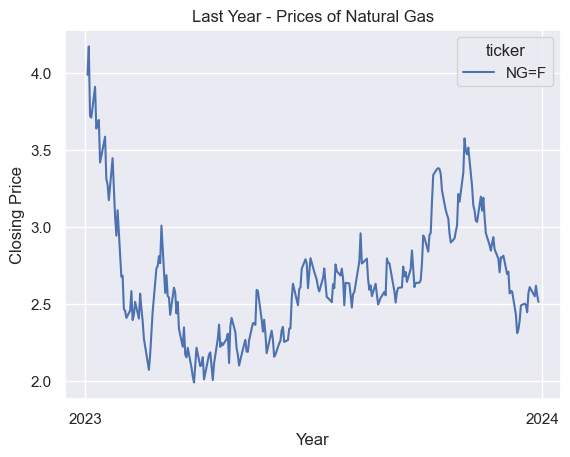

In [19]:
# Plot of year data - Natgas
sns.set(style="darkgrid")
sns.lineplot(x='date',y='close',hue='ticker',data=Oneyr_sub_gas_data)
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xlabel('Year')
plt.ylabel('Closing Price')

plt.title('Last Year - Prices of Natural Gas')
plt.show()

In [20]:
# Establish Start and End Dates
start_date = '2019-01-01'
end_date = '2024-01-01'
# filter our data to only include CL=F and NG=F during the window
Fiveyr_sub_gas_data = natgas_data[(natgas_data['date'] >= start_date) & (natgas_data['date'] <= end_date)]
# Print out head of 5 yr data to ensure the filter was properly applied
Fiveyr_sub_gas_data.head()

,ticker,commodity,date,open,high,low,close,volume
16562,NG=F,Natural Gas,2019-01-02,2.921,3.039,2.905,2.958,147676
16563,NG=F,Natural Gas,2019-01-03,2.963,3.011,2.878,2.945,115803
16564,NG=F,Natural Gas,2019-01-04,2.914,3.049,2.894,3.044,122576
16565,NG=F,Natural Gas,2019-01-07,2.962,2.994,2.910,2.944,109247
16566,NG=F,Natural Gas,2019-01-08,2.950,3.053,2.948,2.967,132229


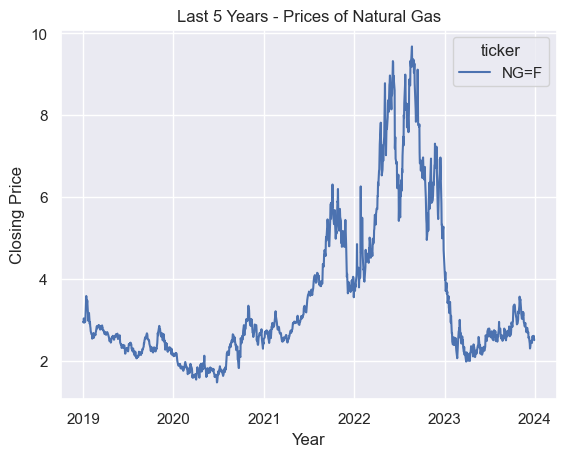

In [21]:
# Plot of 5 year data - Natural Gas
sns.set(style="darkgrid")
sns.lineplot(x='date',y='close',hue='ticker',data=Fiveyr_sub_gas_data)
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xlabel('Year')
plt.ylabel('Closing Price')

plt.title('Last 5 Years - Prices of Natural Gas')
plt.show()

Text(0.5, 1.0, 'Observed')

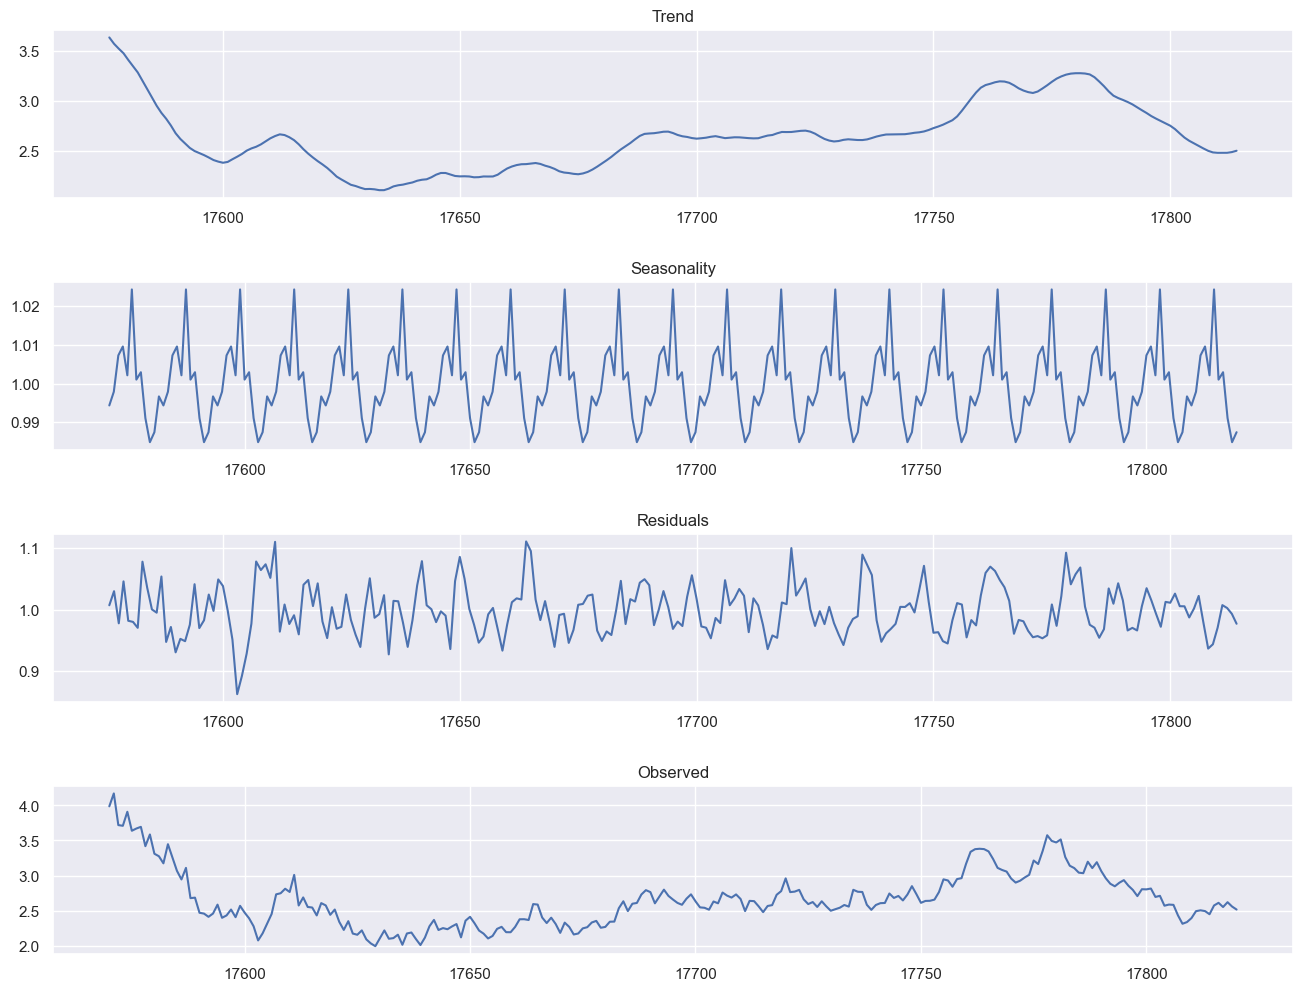

In [22]:
natgas_decompose = seasonal_decompose(Oneyr_sub_gas_data['close'], model='multiplicative',period=12)
# Plot results
plt.figure(figsize=(16,12))
plt.subplots_adjust(hspace=0.5)

plt.subplot(4,1,1)
plt.plot(natgas_decompose.trend)
plt.title('Trend')

plt.subplot(4,1,2)
plt.plot(natgas_decompose.seasonal)
plt.title('Seasonality')

plt.subplot(4,1,3)
plt.plot(natgas_decompose.resid)
plt.title('Residuals')

plt.subplot(4,1,4)
plt.plot(natgas_decompose.observed)
plt.title('Observed')